In [1]:
%pip install -q -U kagglehub ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.2 MB/s eta 0:00:00


In [2]:
import os
import sys
import re
import json
import random
import hashlib
import shutil
import subprocess
import platform
import importlib.metadata
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import imagehash

import sklearn
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
import kagglehub

from tqdm.auto import tqdm


# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    DETERMINISM_STATUS = "TensorFlow op determinism enabled"
except Exception as e:
    DETERMINISM_STATUS = f"Could not fully enable deterministic ops: {e}"


# ---------------------------------------------------------
# Helper for installed package versions
# ---------------------------------------------------------

def package_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except Exception:
        return "unknown"


# ---------------------------------------------------------
# GPU detection
# ---------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    gpu_details = tf.config.experimental.get_device_details(gpus[0])
    GPU_NAME = gpu_details.get("device_name", str(gpus[0]))
else:
    GPU_NAME = "No GPU detected"


try:
    NVIDIA_SMI = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,driver_version,memory.total",
            "--format=csv,noheader"
        ],
        text=True
    ).strip()
except Exception:
    NVIDIA_SMI = "nvidia-smi unavailable"


ENV_INFO = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "keras_version": getattr(keras, "__version__", package_version("keras")),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "kagglehub_version": package_version("kagglehub"),
    "pillow_version": package_version("Pillow"),
    "imagehash_version": package_version("ImageHash"),
    "gpu_name": GPU_NAME,
    "nvidia_smi": NVIDIA_SMI,
    "seed": SEED,
    "determinism_status": DETERMINISM_STATUS
}

print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)

for key, value in ENV_INFO.items():
    print(f"{key}: {value}")

ENVIRONMENT INFORMATION
python_version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.39
tensorflow_version: 2.20.0
keras_version: 3.13.2
numpy_version: 2.1.3
pandas_version: 2.2.3
scikit_learn_version: 1.6.1
kagglehub_version: 1.0.2
pillow_version: 11.3.0
imagehash_version: 4.3.2
gpu_name: Tesla T4
nvidia_smi: Tesla T4, 580.82.07, 15360 MiB
seed: 42
determinism_status: TensorFlow op determinism enabled


In [3]:
# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = Path("/content/brain_tumour_model_comparison")

SPLITS_DIR = PROJECT_DIR / "splits"
DATA_AUDIT_DIR = PROJECT_DIR / "results" / "data_audit"
CONFIG_DIR = PROJECT_DIR / "config"

for directory in [
    PROJECT_DIR,
    SPLITS_DIR,
    DATA_AUDIT_DIR,
    CONFIG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Shared experiment protocol
# ---------------------------------------------------------

EXPECTED_CLASSES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(EXPECTED_CLASSES)
}

SHARED_PROTOCOL = {
    "project_title":
        "Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification",

    "seed": SEED,

    "image_height": 224,
    "image_width": 224,
    "channels": 3,

    "classes": EXPECTED_CLASSES,
    "class_to_index": CLASS_TO_INDEX,

    "batch_size": 16,

    "maximum_epochs": 20,

    "loss_function": "sparse_categorical_crossentropy",

    "output_activation": "softmax",

    "early_stopping_monitor": "val_loss",
    "early_stopping_patience": 4,
    "restore_best_weights": True,

    "validation_fraction_from_original_training": 0.20,

    "test_policy":
        "Original Kaggle Testing directory reserved for final evaluation only",

    "validation_policy":
        "Validation split created only from original Kaggle Training directory",

    "prediction_shuffle": False,

    "augmentation_policy":
        "Identical mild augmentation policy will be applied to training data only.",

    "cnn_preprocessing":
        "Rescaling(1./255)",

    "vgg16_preprocessing":
        "keras.applications.vgg16.preprocess_input",

    "resnet50_preprocessing":
        "keras.applications.resnet50.preprocess_input",

    "densenet121_preprocessing":
        "keras.applications.densenet.preprocess_input"
}


with open(CONFIG_DIR / "shared_protocol.json", "w") as f:
    json.dump(SHARED_PROTOCOL, f, indent=4)


with open(CONFIG_DIR / "environment.json", "w") as f:
    json.dump(ENV_INFO, f, indent=4)


with open(CONFIG_DIR / "class_to_index.json", "w") as f:
    json.dump(CLASS_TO_INDEX, f, indent=4)


print("Shared protocol saved.")
print("\nClass mapping:")
print(CLASS_TO_INDEX)

print("\nProject directory:")
print(PROJECT_DIR)

Shared protocol saved.

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Project directory:
/content/brain_tumour_model_comparison


In [5]:
# ---------------------------------------------------------
# Freeze the exact Kaggle dataset version
# ---------------------------------------------------------

DATASET_HANDLE = "masoudnickparvar/brain-tumor-mri-dataset"

# Verified from the Kaggle dataset page
DATASET_VERSION = 1

PINNED_DATASET_HANDLE = (
    f"{DATASET_HANDLE}/versions/{DATASET_VERSION}"
)

print("=" * 70)
print("DATASET VERSION FREEZE")
print("=" * 70)

print("Dataset handle:")
print(DATASET_HANDLE)

print("\nPinned dataset version:")
print(DATASET_VERSION)

print("\nPinned Kaggle handle:")
print(PINNED_DATASET_HANDLE)


# ---------------------------------------------------------
# Request the exact pinned version
# ---------------------------------------------------------

DATASET_ROOT = Path(
    kagglehub.dataset_download(
        PINNED_DATASET_HANDLE
    )
).resolve()


print("\nResolved dataset path:")
print(DATASET_ROOT)


# ---------------------------------------------------------
# Basic verification
# ---------------------------------------------------------

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset path does not exist: {DATASET_ROOT}"
    )


print("\n✓ Dataset downloaded/resolved successfully.")
print(f"✓ Dataset version frozen as Version {DATASET_VERSION}.")
print("✓ All four members must use this same pinned version.")

DATASET VERSION FREEZE
Dataset handle:
masoudnickparvar/brain-tumor-mri-dataset

Pinned dataset version:
1

Pinned Kaggle handle:
masoudnickparvar/brain-tumor-mri-dataset/versions/1
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.

Resolved dataset path:
/kaggle/input/brain-tumor-mri-dataset

✓ Dataset downloaded/resolved successfully.
✓ Dataset version frozen as Version 1.
✓ All four members must use this same pinned version.


In [6]:
def find_named_directory(root, directory_name):
    matches = [
        path
        for path in root.rglob(directory_name)
        if path.is_dir()
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{directory_name}' inside {root}"
        )

    if len(matches) > 1:
        print(
            f"WARNING: Found multiple '{directory_name}' directories:"
        )

        for match in matches:
            print(" -", match)

    return matches[0]


TRAINING_DIR = find_named_directory(DATASET_ROOT, "Training")
TESTING_DIR = find_named_directory(DATASET_ROOT, "Testing")


print("Training directory:")
print(TRAINING_DIR)

print("\nTesting directory:")
print(TESTING_DIR)


training_classes = sorted([
    folder.name
    for folder in TRAINING_DIR.iterdir()
    if folder.is_dir()
])

testing_classes = sorted([
    folder.name
    for folder in TESTING_DIR.iterdir()
    if folder.is_dir()
])


print("\nTraining classes:")
print(training_classes)

print("\nTesting classes:")
print(testing_classes)


assert training_classes == EXPECTED_CLASSES, (
    f"Training classes do not match expected classes.\n"
    f"Expected: {EXPECTED_CLASSES}\n"
    f"Found: {training_classes}"
)

assert testing_classes == EXPECTED_CLASSES, (
    f"Testing classes do not match expected classes.\n"
    f"Expected: {EXPECTED_CLASSES}\n"
    f"Found: {testing_classes}"
)


print("\nSUCCESS: Exactly four expected classes were verified.")

Training directory:
/kaggle/input/brain-tumor-mri-dataset/Training

Testing directory:
/kaggle/input/brain-tumor-mri-dataset/Testing

Training classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

SUCCESS: Exactly four expected classes were verified.


In [7]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    hasher = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            hasher.update(chunk)

    return hasher.hexdigest()


def get_image_files(directory):
    return sorted([
        path
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])


def inspect_images(source_directory, source_name):
    image_files = get_image_files(source_directory)

    rows = []

    print(
        f"{source_name}: inspecting {len(image_files)} image files"
    )

    for file_path in tqdm(
        image_files,
        desc=f"Scanning {source_name}"
    ):

        relative_to_split = file_path.relative_to(source_directory)

        # First path component should be the class folder
        label = relative_to_split.parts[0]

        relative_to_dataset = file_path.relative_to(
            DATASET_ROOT
        ).as_posix()

        row = {
            "source_split": source_name,
            "filepath": relative_to_dataset,
            "label": label,
            "file_size_bytes": file_path.stat().st_size,
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "sha256": None,
            "phash": None,
            "valid_image": False,
            "error": None
        }

        try:
            # Exact content fingerprint
            row["sha256"] = calculate_sha256(file_path)

            # Decode image and inspect metadata
            with Image.open(file_path) as img:
                img.load()

                row["width"], row["height"] = img.size
                row["mode"] = img.mode
                row["format"] = img.format

                # Perceptual hash for duplicate/similarity screening
                grayscale_img = img.convert("L")
                row["phash"] = str(
                    imagehash.phash(grayscale_img)
                )

            row["valid_image"] = True

        except Exception as error:
            row["error"] = str(error)

        rows.append(row)

    return pd.DataFrame(rows)


training_inventory = inspect_images(
    TRAINING_DIR,
    "Training"
)

testing_inventory = inspect_images(
    TESTING_DIR,
    "Testing"
)


inventory_df = pd.concat(
    [training_inventory, testing_inventory],
    ignore_index=True
)


inventory_df.to_csv(
    DATA_AUDIT_DIR / "image_inventory.csv",
    index=False
)


corrupt_df = inventory_df[
    ~inventory_df["valid_image"]
].copy()


corrupt_df.to_csv(
    DATA_AUDIT_DIR / "corrupt_images.csv",
    index=False
)


print("\n" + "=" * 70)
print("IMAGE INVENTORY SUMMARY")
print("=" * 70)

print("Total candidate images:", len(inventory_df))
print("Valid images:", inventory_df["valid_image"].sum())
print("Unreadable/corrupt images:", len(corrupt_df))


if len(corrupt_df) > 0:
    print("\nCorrupt/unreadable files:")
    display(
        corrupt_df[
            ["source_split", "filepath", "label", "error"]
        ]
    )
else:
    print("\nNo corrupt images detected.")

Training: inspecting 5712 image files


Scanning Training:   0%|          | 0/5712 [00:00<?, ?it/s]

Testing: inspecting 1311 image files


Scanning Testing:   0%|          | 0/1311 [00:00<?, ?it/s]


IMAGE INVENTORY SUMMARY
Total candidate images: 7023
Valid images: 7023
Unreadable/corrupt images: 0

No corrupt images detected.


Class distribution:


label,glioma,meningioma,notumor,pituitary
source_split,,,,
Testing,300,306,405,300
Training,1321,1339,1595,1457


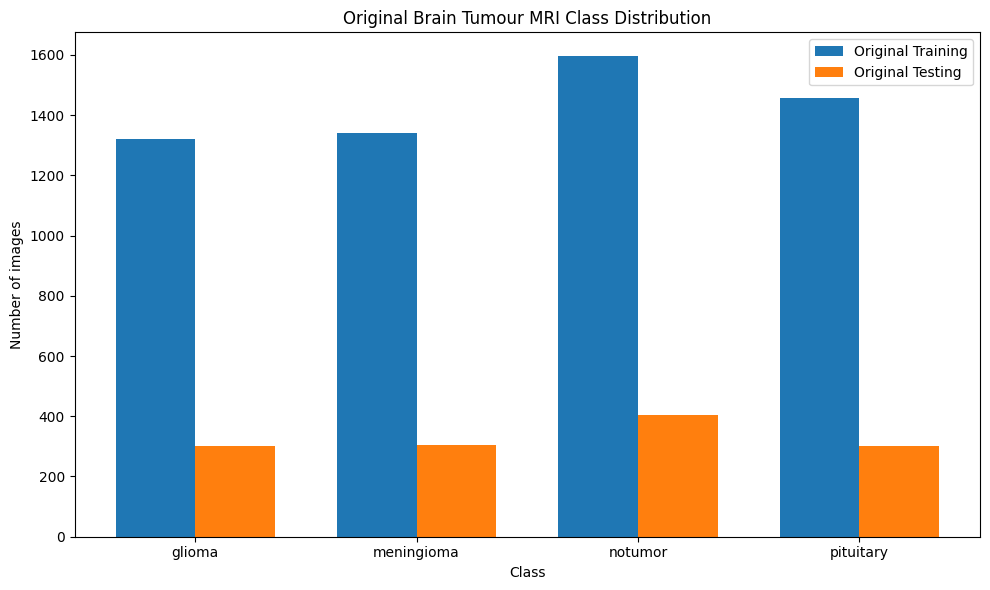


Training total: 5712
Testing total: 1311
Overall total: 7023


In [8]:
clean_inventory_df = inventory_df[
    inventory_df["valid_image"]
].copy()


distribution_df = (
    clean_inventory_df
    .groupby(["source_split", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=EXPECTED_CLASSES)
)


print("Class distribution:")
display(distribution_df)


distribution_df.to_csv(
    DATA_AUDIT_DIR / "original_class_distribution.csv"
)


# ---------------------------------------------------------
# Plot class distribution
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(EXPECTED_CLASSES))
bar_width = 0.36

training_counts = distribution_df.loc[
    "Training",
    EXPECTED_CLASSES
].values

testing_counts = distribution_df.loc[
    "Testing",
    EXPECTED_CLASSES
].values


ax.bar(
    x - bar_width / 2,
    training_counts,
    bar_width,
    label="Original Training"
)

ax.bar(
    x + bar_width / 2,
    testing_counts,
    bar_width,
    label="Original Testing"
)

ax.set_title("Original Brain Tumour MRI Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_xticks(x)
ax.set_xticklabels(EXPECTED_CLASSES)
ax.legend()

plt.tight_layout()

class_plot_path = (
    DATA_AUDIT_DIR /
    "original_class_distribution.png"
)

plt.savefig(
    class_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nTraining total:", int(training_counts.sum()))
print("Testing total:", int(testing_counts.sum()))
print(
    "Overall total:",
    int(training_counts.sum() + testing_counts.sum())
)

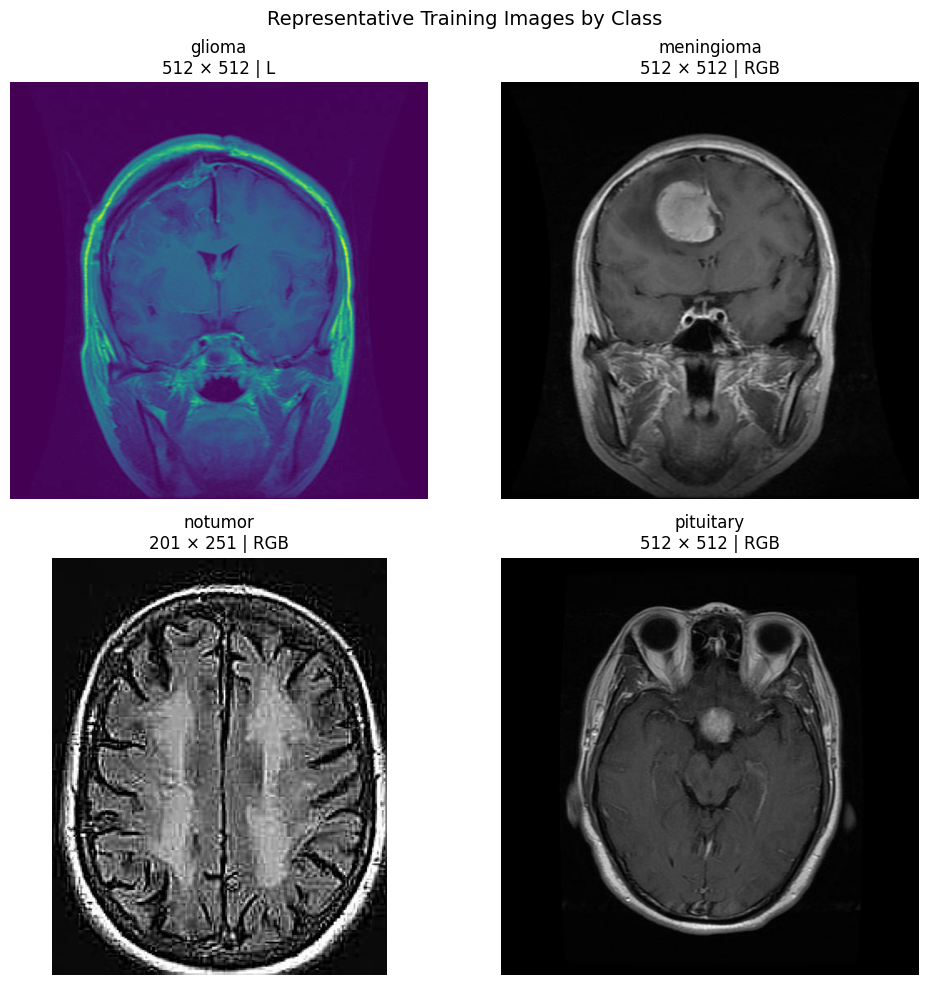

In [9]:
training_clean_df = clean_inventory_df[
    clean_inventory_df["source_split"] == "Training"
].copy()


fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10)
)

axes = axes.flatten()


for index, class_name in enumerate(EXPECTED_CLASSES):

    class_df = training_clean_df[
        training_clean_df["label"] == class_name
    ]

    sample_row = class_df.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    image_path = (
        DATASET_ROOT /
        sample_row["filepath"]
    )

    with Image.open(image_path) as img:
        axes[index].imshow(img)

    axes[index].set_title(
        f"{class_name}\n"
        f"{sample_row['width']} × {sample_row['height']} | "
        f"{sample_row['mode']}"
    )

    axes[index].axis("off")


plt.suptitle(
    "Representative Training Images by Class",
    fontsize=14
)

plt.tight_layout()


sample_plot_path = (
    DATA_AUDIT_DIR /
    "representative_samples.png"
)

plt.savefig(
    sample_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

MOST COMMON IMAGE DIMENSIONS


,width,height,count
324,512,512,4742
89,225,225,332
348,630,630,90
149,236,236,81
21,201,251,58
99,228,221,51
109,232,217,50
210,300,168,49
291,442,442,46
0,150,198,44



IMAGE MODES


,mode,count
0,RGB,3926
1,L,3093
2,RGBA,3
3,P,1



IMAGE FORMATS


,format,count
0,JPEG,7018
1,PNG,5


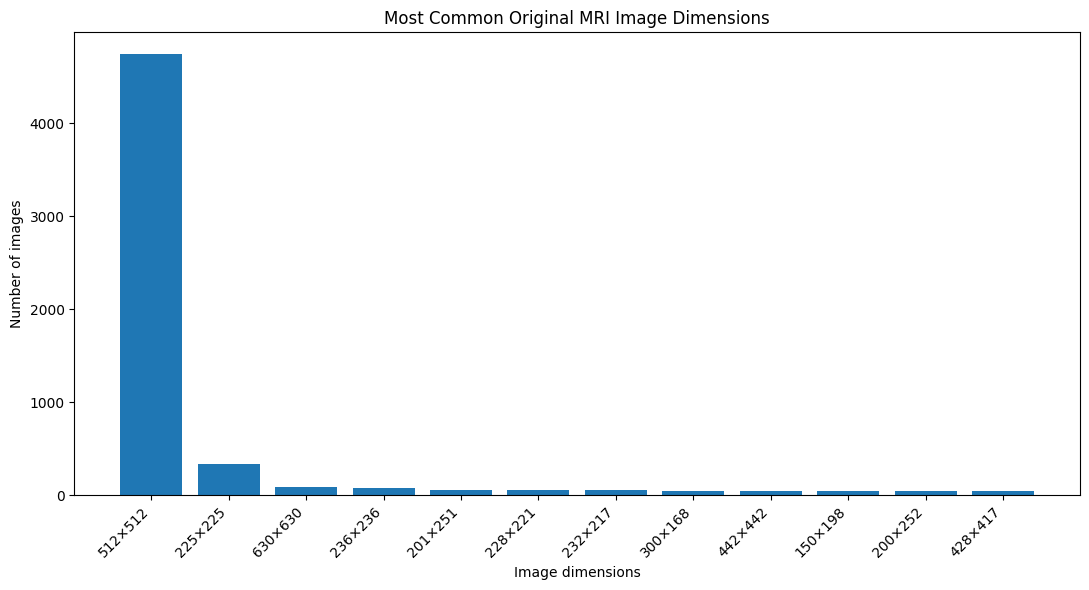

Checking RGB/grayscale behaviour:   0%|          | 0/400 [00:00<?, ?it/s]


Sampled 400 images.
Effectively grayscale after RGB conversion: 97.75%


In [10]:
# ---------------------------------------------------------
# Dimensions
# ---------------------------------------------------------

dimension_counts = (
    clean_inventory_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)


mode_counts = (
    clean_inventory_df["mode"]
    .value_counts()
    .rename_axis("mode")
    .reset_index(name="count")
)


format_counts = (
    clean_inventory_df["format"]
    .value_counts()
    .rename_axis("format")
    .reset_index(name="count")
)


dimension_counts.to_csv(
    DATA_AUDIT_DIR / "image_dimension_counts.csv",
    index=False
)

mode_counts.to_csv(
    DATA_AUDIT_DIR / "image_mode_counts.csv",
    index=False
)

format_counts.to_csv(
    DATA_AUDIT_DIR / "image_format_counts.csv",
    index=False
)


print("=" * 60)
print("MOST COMMON IMAGE DIMENSIONS")
print("=" * 60)

display(dimension_counts.head(15))


print("\nIMAGE MODES")
display(mode_counts)


print("\nIMAGE FORMATS")
display(format_counts)


# ---------------------------------------------------------
# Dimension visualization
# ---------------------------------------------------------

top_dimensions = dimension_counts.head(12).copy()

dimension_labels = (
    top_dimensions["width"].astype(int).astype(str)
    + "×"
    + top_dimensions["height"].astype(int).astype(str)
)


plt.figure(figsize=(11, 6))

plt.bar(
    dimension_labels,
    top_dimensions["count"]
)

plt.title("Most Common Original MRI Image Dimensions")
plt.xlabel("Image dimensions")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    DATA_AUDIT_DIR / "image_dimensions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Sample actual channel behaviour
# ---------------------------------------------------------

CHANNEL_SAMPLE_SIZE = min(
    400,
    len(clean_inventory_df)
)

channel_sample = clean_inventory_df.sample(
    n=CHANNEL_SAMPLE_SIZE,
    random_state=SEED
).copy()


channel_results = []


for _, row in tqdm(
    channel_sample.iterrows(),
    total=len(channel_sample),
    desc="Checking RGB/grayscale behaviour"
):

    image_path = DATASET_ROOT / row["filepath"]

    with Image.open(image_path) as img:
        rgb_array = np.asarray(
            img.convert("RGB")
        )

    effectively_grayscale = (
        np.array_equal(
            rgb_array[:, :, 0],
            rgb_array[:, :, 1]
        )
        and
        np.array_equal(
            rgb_array[:, :, 1],
            rgb_array[:, :, 2]
        )
    )

    channel_results.append({
        "filepath": row["filepath"],
        "label": row["label"],
        "original_mode": row["mode"],
        "effectively_grayscale_rgb": effectively_grayscale
    })


channel_behavior_df = pd.DataFrame(
    channel_results
)


channel_behavior_df.to_csv(
    DATA_AUDIT_DIR / "channel_behavior_sample.csv",
    index=False
)


grayscale_percentage = (
    channel_behavior_df[
        "effectively_grayscale_rgb"
    ].mean() * 100
)


print(
    f"\nSampled {CHANNEL_SAMPLE_SIZE} images."
)

print(
    f"Effectively grayscale after RGB conversion: "
    f"{grayscale_percentage:.2f}%"
)

In [11]:
# ---------------------------------------------------------
# Exact duplicates using SHA-256
# ---------------------------------------------------------

exact_duplicate_df = clean_inventory_df[
    clean_inventory_df.duplicated(
        subset=["sha256"],
        keep=False
    )
].sort_values("sha256")


exact_duplicate_df.to_csv(
    DATA_AUDIT_DIR / "exact_duplicate_images.csv",
    index=False
)


# ---------------------------------------------------------
# Perceptual-hash collisions
# ---------------------------------------------------------

phash_collision_df = clean_inventory_df[
    clean_inventory_df.duplicated(
        subset=["phash"],
        keep=False
    )
].sort_values("phash")


phash_collision_df.to_csv(
    DATA_AUDIT_DIR / "perceptual_hash_collisions.csv",
    index=False
)


# ---------------------------------------------------------
# Train/Test exact hash overlap
# ---------------------------------------------------------

original_training_df = clean_inventory_df[
    clean_inventory_df["source_split"] == "Training"
].copy()


original_testing_df = clean_inventory_df[
    clean_inventory_df["source_split"] == "Testing"
].copy()


training_hashes = set(
    original_training_df["sha256"]
)

testing_hashes = set(
    original_testing_df["sha256"]
)


cross_split_exact_hashes = (
    training_hashes &
    testing_hashes
)


train_test_exact_overlap_df = clean_inventory_df[
    clean_inventory_df["sha256"].isin(
        cross_split_exact_hashes
    )
].sort_values("sha256")


train_test_exact_overlap_df.to_csv(
    DATA_AUDIT_DIR /
    "original_train_test_exact_overlap.csv",
    index=False
)


# ---------------------------------------------------------
# Train/Test perceptual-hash collisions
# ---------------------------------------------------------

training_phashes = set(
    original_training_df["phash"]
)

testing_phashes = set(
    original_testing_df["phash"]
)


cross_split_phashes = (
    training_phashes &
    testing_phashes
)


train_test_phash_collision_df = clean_inventory_df[
    clean_inventory_df["phash"].isin(
        cross_split_phashes
    )
].sort_values("phash")


train_test_phash_collision_df.to_csv(
    DATA_AUDIT_DIR /
    "original_train_test_phash_collisions.csv",
    index=False
)


# ---------------------------------------------------------
# Check for identical files assigned conflicting labels
# ---------------------------------------------------------

hash_label_counts = (
    clean_inventory_df
    .groupby("sha256")["label"]
    .nunique()
)


conflicting_hashes = set(
    hash_label_counts[
        hash_label_counts > 1
    ].index
)


conflicting_label_df = clean_inventory_df[
    clean_inventory_df["sha256"].isin(
        conflicting_hashes
    )
].sort_values("sha256")


conflicting_label_df.to_csv(
    DATA_AUDIT_DIR /
    "duplicate_label_conflicts.csv",
    index=False
)


# ---------------------------------------------------------
# Dataset image-content fingerprint
# ---------------------------------------------------------

fingerprint_rows = clean_inventory_df[
    [
        "filepath",
        "file_size_bytes",
        "sha256"
    ]
].sort_values("filepath")


fingerprint_string = "\n".join(
    f"{row.filepath}|"
    f"{row.file_size_bytes}|"
    f"{row.sha256}"

    for row in fingerprint_rows.itertuples(
        index=False
    )
)


DATASET_FINGERPRINT = hashlib.sha256(
    fingerprint_string.encode("utf-8")
).hexdigest()


print("=" * 70)
print("DUPLICATE / LEAKAGE AUDIT")
print("=" * 70)

print(
    "Images belonging to an exact duplicate group:",
    len(exact_duplicate_df)
)

print(
    "Images belonging to a pHash collision group:",
    len(phash_collision_df)
)

print(
    "Exact hash values appearing in both original "
    "Training and Testing:",
    len(cross_split_exact_hashes)
)

print(
    "pHash values appearing in both original "
    "Training and Testing:",
    len(cross_split_phashes)
)

print(
    "Exact duplicate hashes with conflicting labels:",
    len(conflicting_hashes)
)

print("\nDataset fingerprint:")
print(DATASET_FINGERPRINT)


if len(conflicting_hashes) > 0:
    print(
        "\nWARNING: Identical image bytes occur under "
        "different labels."
    )

    display(conflicting_label_df)

DUPLICATE / LEAKAGE AUDIT
Images belonging to an exact duplicate group: 491
Images belonging to a pHash collision group: 1732
Exact hash values appearing in both original Training and Testing: 79
pHash values appearing in both original Training and Testing: 349
Exact duplicate hashes with conflicting labels: 0

Dataset fingerprint:
061cbffb7341abf85e57a4f99de571e8fa4702ec8236c929e35543ab0547217d


In [12]:
DATASET_METADATA = {
    "dataset_name": "Brain Tumor MRI Dataset",

    "creator_from_kaggle_handle":
        "masoudnickparvar",

    "kaggle_handle":
        DATASET_HANDLE,

    "observed_dataset_version":
        DATASET_VERSION,

    "pinned_dataset_handle":
        PINNED_DATASET_HANDLE,

    "resolved_dataset_path":
        str(DATASET_ROOT),

    "dataset_url":
        "https://www.kaggle.com/datasets/"
        "masoudnickparvar/brain-tumor-mri-dataset",

    "classes":
        EXPECTED_CLASSES,

    "number_of_classes":
        len(EXPECTED_CLASSES),

    "valid_image_count":
        int(len(clean_inventory_df)),

    "corrupt_image_count":
        int(len(corrupt_df)),

    "original_training_count":
        int(len(original_training_df)),

    "original_testing_count":
        int(len(original_testing_df)),

    "dataset_image_fingerprint_sha256":
        DATASET_FINGERPRINT,

    "exact_cross_split_duplicate_hash_count":
        int(len(cross_split_exact_hashes)),

    "perceptual_cross_split_hash_collision_count":
        int(len(cross_split_phashes)),

    "patient_level_separation_verified":
        False,

    "patient_level_note":
        "Reliable patient identifiers have not been established "
        "from the available directory/file structure. "
        "Patient-level separation must therefore not be claimed.",

    "license":
        None,

    "license_note":
        "Verify and record the licence shown on the Kaggle "
        "dataset page before final report submission."
}


with open(
    DATA_AUDIT_DIR / "dataset_metadata.json",
    "w"
) as f:

    json.dump(
        DATASET_METADATA,
        f,
        indent=4
    )


print(json.dumps(DATASET_METADATA, indent=4))

{
    "dataset_name": "Brain Tumor MRI Dataset",
    "creator_from_kaggle_handle": "masoudnickparvar",
    "kaggle_handle": "masoudnickparvar/brain-tumor-mri-dataset",
    "observed_dataset_version": 1,
    "pinned_dataset_handle": "masoudnickparvar/brain-tumor-mri-dataset/versions/1",
    "resolved_dataset_path": "/kaggle/input/brain-tumor-mri-dataset",
    "dataset_url": "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "classes": [
        "glioma",
        "meningioma",
        "notumor",
        "pituitary"
    ],
    "number_of_classes": 4,
    "valid_image_count": 7023,
    "corrupt_image_count": 0,
    "original_training_count": 5712,
    "original_testing_count": 1311,
    "dataset_image_fingerprint_sha256": "061cbffb7341abf85e57a4f99de571e8fa4702ec8236c929e35543ab0547217d",
    "exact_cross_split_duplicate_hash_count": 79,
    "perceptual_cross_split_hash_collision_count": 349,
    "patient_level_separation_verified": false,
    "patient_level_no

In [13]:
# ---------------------------------------------------------
# Start from valid Training / Testing images
# ---------------------------------------------------------

training_candidates = (
    original_training_df
    .sort_values("filepath")
    .copy()
)

testing_final_candidates = (
    original_testing_df
    .sort_values("filepath")
    .copy()
)


# ---------------------------------------------------------
# Safety check: exact duplicate conflicting labels
# ---------------------------------------------------------

if len(conflicting_hashes) > 0:
    raise RuntimeError(
        "Exact duplicate files with conflicting labels were "
        "detected. STOP and send me duplicate_label_conflicts.csv "
        "before generating the frozen splits."
    )


# ---------------------------------------------------------
# Remove repeated exact copies INSIDE Training
# Keep deterministic first filepath
# ---------------------------------------------------------

training_duplicate_mask = (
    training_candidates.duplicated(
        subset=["sha256"],
        keep="first"
    )
)


excluded_training_duplicates = (
    training_candidates[
        training_duplicate_mask
    ].copy()
)


training_candidates = (
    training_candidates[
        ~training_duplicate_mask
    ].copy()
)


excluded_training_duplicates.to_csv(
    DATA_AUDIT_DIR /
    "excluded_internal_training_duplicates.csv",
    index=False
)


# ---------------------------------------------------------
# Remove Training files whose exact bytes appear in Testing
# Testing itself remains unchanged
# ---------------------------------------------------------

test_hash_set = set(
    testing_final_candidates["sha256"]
)


train_test_leak_mask = (
    training_candidates["sha256"].isin(
        test_hash_set
    )
)


excluded_training_test_overlap = (
    training_candidates[
        train_test_leak_mask
    ].copy()
)


training_candidates = (
    training_candidates[
        ~train_test_leak_mask
    ].copy()
)


excluded_training_test_overlap.to_csv(
    DATA_AUDIT_DIR /
    "excluded_training_due_to_test_overlap.csv",
    index=False
)


print("Original valid Training images:")
print(len(original_training_df))

print("\nRemoved duplicate copies inside Training:")
print(len(excluded_training_duplicates))

print("\nRemoved Training images exactly duplicated in Testing:")
print(len(excluded_training_test_overlap))

print("\nFinal Training candidate pool before train/validation split:")
print(len(training_candidates))

print("\nFinal held-out Testing images:")
print(len(testing_final_candidates))

Original valid Training images:
5712

Removed duplicate copies inside Training:
191

Removed Training images exactly duplicated in Testing:
79

Final Training candidate pool before train/validation split:
5442

Final held-out Testing images:
1311


In [14]:
# ---------------------------------------------------------
# Stratified split: Training -> Train + Validation
# ---------------------------------------------------------

train_df, val_df = train_test_split(
    training_candidates,
    test_size=0.20,
    random_state=SEED,
    stratify=training_candidates["label"]
)


# Sort before saving so CSV order is deterministic
train_df = train_df.sort_values(
    "filepath"
).reset_index(drop=True)

val_df = val_df.sort_values(
    "filepath"
).reset_index(drop=True)

test_df = testing_final_candidates.sort_values(
    "filepath"
).reset_index(drop=True)


# ---------------------------------------------------------
# Keep only information required by later notebooks
# SHA-256 is retained for integrity verification
# ---------------------------------------------------------

MANIFEST_COLUMNS = [
    "filepath",
    "label",
    "sha256"
]


train_manifest = train_df[
    MANIFEST_COLUMNS
].copy()

val_manifest = val_df[
    MANIFEST_COLUMNS
].copy()

test_manifest = test_df[
    MANIFEST_COLUMNS
].copy()


# ---------------------------------------------------------
# Save manifests
# ---------------------------------------------------------

TRAIN_CSV = SPLITS_DIR / "train.csv"
VAL_CSV = SPLITS_DIR / "val.csv"
TEST_CSV = SPLITS_DIR / "test.csv"


train_manifest.to_csv(
    TRAIN_CSV,
    index=False
)

val_manifest.to_csv(
    VAL_CSV,
    index=False
)

test_manifest.to_csv(
    TEST_CSV,
    index=False
)


print("Frozen split manifests created:")
print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

Frozen split manifests created:
/content/brain_tumour_model_comparison/splits/train.csv
/content/brain_tumour_model_comparison/splits/val.csv
/content/brain_tumour_model_comparison/splits/test.csv


In [15]:
# ---------------------------------------------------------
# Basic class verification
# ---------------------------------------------------------

for split_name, manifest in [
    ("train", train_manifest),
    ("validation", val_manifest),
    ("test", test_manifest)
]:

    found_classes = sorted(
        manifest["label"].unique().tolist()
    )

    assert found_classes == EXPECTED_CLASSES, (
        f"{split_name} class mismatch. "
        f"Found: {found_classes}"
    )


# ---------------------------------------------------------
# Filepath overlap
# ---------------------------------------------------------

train_paths = set(train_manifest["filepath"])
val_paths = set(val_manifest["filepath"])
test_paths = set(test_manifest["filepath"])


assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)


# ---------------------------------------------------------
# Exact image-content overlap
# ---------------------------------------------------------

train_hashes = set(train_manifest["sha256"])
val_hashes = set(val_manifest["sha256"])
test_hashes = set(test_manifest["sha256"])


assert train_hashes.isdisjoint(val_hashes), (
    "Exact image leakage between train and validation!"
)

assert train_hashes.isdisjoint(test_hashes), (
    "Exact image leakage between train and test!"
)

assert val_hashes.isdisjoint(test_hashes), (
    "Exact image leakage between validation and test!"
)


# ---------------------------------------------------------
# Check every manifest file exists
# ---------------------------------------------------------

def verify_files_exist(manifest):
    missing = []

    for relative_path in manifest["filepath"]:
        full_path = DATASET_ROOT / relative_path

        if not full_path.exists():
            missing.append(relative_path)

    return missing


missing_train = verify_files_exist(train_manifest)
missing_val = verify_files_exist(val_manifest)
missing_test = verify_files_exist(test_manifest)


assert len(missing_train) == 0
assert len(missing_val) == 0
assert len(missing_test) == 0


# ---------------------------------------------------------
# Split summary
# ---------------------------------------------------------

def split_class_counts(manifest, split_name):
    counts = (
        manifest["label"]
        .value_counts()
        .reindex(EXPECTED_CLASSES)
        .fillna(0)
        .astype(int)
    )

    result = counts.to_frame(name="count")
    result["split"] = split_name
    result["class"] = result.index

    return result.reset_index(drop=True)


split_summary = pd.concat([
    split_class_counts(
        train_manifest,
        "train"
    ),
    split_class_counts(
        val_manifest,
        "validation"
    ),
    split_class_counts(
        test_manifest,
        "test"
    )
], ignore_index=True)


split_summary.to_csv(
    DATA_AUDIT_DIR /
    "frozen_split_class_counts.csv",
    index=False
)


print("=" * 70)
print("FROZEN SPLIT VERIFICATION")
print("=" * 70)

print("Train images:", len(train_manifest))
print("Validation images:", len(val_manifest))
print("Test images:", len(test_manifest))

print("\nClass counts:")
display(
    split_summary.pivot(
        index="class",
        columns="split",
        values="count"
    ).reindex(EXPECTED_CLASSES)
)

print("\n✓ No filepath overlap")
print("✓ No exact SHA-256 overlap between splits")
print("✓ All referenced files exist")
print("✓ Four classes exist in every split")
print("✓ Testing folder was never used for validation splitting")

FROZEN SPLIT VERIFICATION
Train images: 4353
Validation images: 1089
Test images: 1311

Class counts:


split,test,train,validation
class,,,
glioma,300,1057,264
meningioma,306,1064,267
notumor,405,1080,270
pituitary,300,1152,288



✓ No filepath overlap
✓ No exact SHA-256 overlap between splits
✓ All referenced files exist
✓ Four classes exist in every split
✓ Testing folder was never used for validation splitting


split,test,train,validation
class,,,
glioma,300,1057,264
meningioma,306,1064,267
notumor,405,1080,270
pituitary,300,1152,288


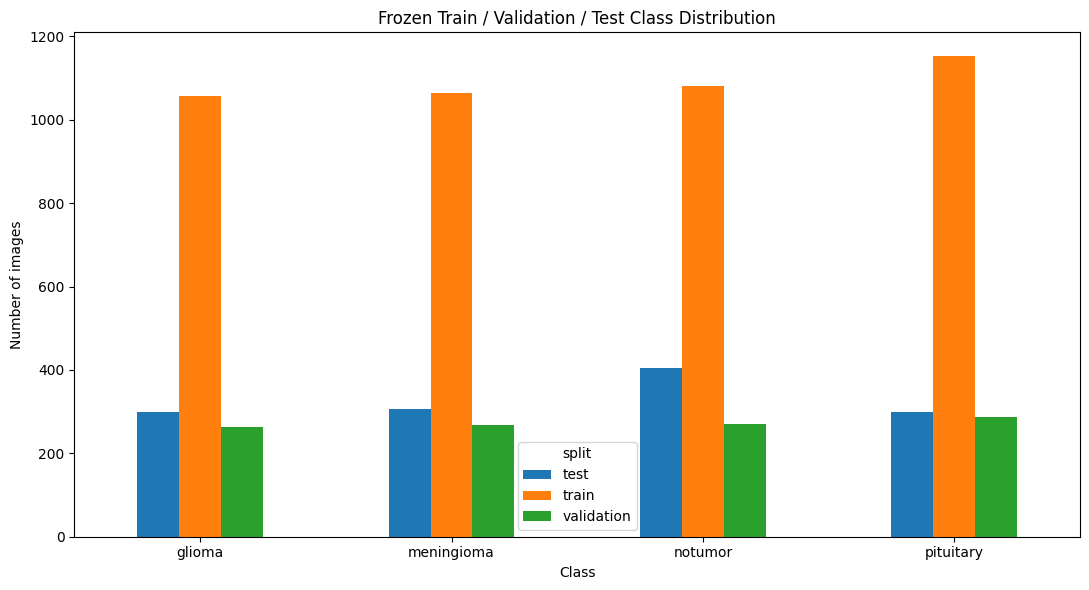

In [16]:
final_distribution = (
    split_summary.pivot(
        index="class",
        columns="split",
        values="count"
    )
    .reindex(EXPECTED_CLASSES)
)


display(final_distribution)


ax = final_distribution.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Frozen Train / Validation / Test Class Distribution"
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of images")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    DATA_AUDIT_DIR /
    "frozen_split_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [17]:
def sha256_of_file(file_path):
    hasher = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            hasher.update(chunk)

    return hasher.hexdigest()


SPLIT_CHECKSUMS = {
    "train.csv": sha256_of_file(TRAIN_CSV),
    "val.csv": sha256_of_file(VAL_CSV),
    "test.csv": sha256_of_file(TEST_CSV)
}


with open(
    SPLITS_DIR / "split_checksums.json",
    "w"
) as f:

    json.dump(
        SPLIT_CHECKSUMS,
        f,
        indent=4
    )


print("FROZEN SPLIT CHECKSUMS")
print("=" * 70)

for file_name, checksum in SPLIT_CHECKSUMS.items():
    print(f"{file_name}")
    print(checksum)
    print()

FROZEN SPLIT CHECKSUMS
train.csv
7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb

val.csv
37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f

test.csv
9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39



In [18]:
PHASE1_CONFIG = {
    "member": 1,
    "phase": 1,

    "dataset_handle":
        DATASET_HANDLE,

    "dataset_version":
        DATASET_VERSION,

    "pinned_dataset_handle":
        PINNED_DATASET_HANDLE,

    "dataset_fingerprint":
        DATASET_FINGERPRINT,

    "seed":
        SEED,

    "original_training_valid_images":
        int(len(original_training_df)),

    "original_testing_valid_images":
        int(len(original_testing_df)),

    "excluded_corrupt_images":
        int(len(corrupt_df)),

    "excluded_internal_training_duplicates":
        int(len(excluded_training_duplicates)),

    "excluded_training_test_exact_overlaps":
        int(len(excluded_training_test_overlap)),

    "frozen_train_count":
        int(len(train_manifest)),

    "frozen_validation_count":
        int(len(val_manifest)),

    "frozen_test_count":
        int(len(test_manifest)),

    "validation_fraction":
        0.20,

    "split_method":
        "sklearn train_test_split with stratification",

    "test_policy":
        "Original Testing directory kept as held-out final test set",

    "patient_level_split_verified":
        False
}


with open(
    CONFIG_DIR / "phase1_config.json",
    "w"
) as f:

    json.dump(
        PHASE1_CONFIG,
        f,
        indent=4
    )


requirements = [
    f"tensorflow=={tf.__version__}",
    f"keras=={getattr(keras, '__version__', package_version('keras'))}",
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"kagglehub=={package_version('kagglehub')}",
    f"Pillow=={package_version('Pillow')}",
    f"ImageHash=={package_version('ImageHash')}"
]


with open(
    PROJECT_DIR / "requirements.txt",
    "w"
) as f:

    f.write("\n".join(requirements))


print("Phase 1 configuration saved.")
print("\nrequirements.txt:")
print("\n".join(requirements))

Phase 1 configuration saved.

requirements.txt:
tensorflow==2.20.0
keras==3.13.2
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
kagglehub==1.0.2
Pillow==11.3.0
ImageHash==4.3.2


In [19]:
print("=" * 78)
print("MEMBER 1 — PHASE 1 FINAL SUMMARY")
print("=" * 78)

print(f"Dataset version           : {DATASET_VERSION}")
print(f"Pinned Kaggle handle      : {PINNED_DATASET_HANDLE}")

print(
    f"Dataset fingerprint       : "
    f"{DATASET_FINGERPRINT}"
)

print()
print(f"Valid original Training   : {len(original_training_df)}")
print(f"Valid original Testing    : {len(original_testing_df)}")
print(f"Corrupt images            : {len(corrupt_df)}")

print()
print(
    "Internal Training duplicates excluded :",
    len(excluded_training_duplicates)
)

print(
    "Train/Test exact overlaps excluded     :",
    len(excluded_training_test_overlap)
)

print()
print(f"Frozen Train              : {len(train_manifest)}")
print(f"Frozen Validation         : {len(val_manifest)}")
print(f"Frozen Test               : {len(test_manifest)}")

print()
print("Classes:")
print(EXPECTED_CLASSES)

print()
print("Split checksums:")

for file_name, checksum in SPLIT_CHECKSUMS.items():
    print(f"{file_name}: {checksum}")

print()
print("GPU:")
print(GPU_NAME)

print()
print(
    "Patient-level independence verified: NO"
)

print(
    "Reason: reliable patient identifiers have not "
    "yet been established."
)

print()
print("PHASE 1 STATUS:")
print("✓ Dataset downloaded")
print("✓ Dataset version pinned")
print("✓ Dataset audited")
print("✓ EDA completed")
print("✓ Corrupt-image screening completed")
print("✓ Duplicate screening completed")
print("✓ Original Testing preserved")
print("✓ Stratified validation split created from Training")
print("✓ Frozen CSV manifests created")
print("✓ Leakage checks passed")
print("✓ No model training performed")

MEMBER 1 — PHASE 1 FINAL SUMMARY
Dataset version           : 1
Pinned Kaggle handle      : masoudnickparvar/brain-tumor-mri-dataset/versions/1
Dataset fingerprint       : 061cbffb7341abf85e57a4f99de571e8fa4702ec8236c929e35543ab0547217d

Valid original Training   : 5712
Valid original Testing    : 1311
Corrupt images            : 0

Internal Training duplicates excluded : 191
Train/Test exact overlaps excluded     : 79

Frozen Train              : 4353
Frozen Validation         : 1089
Frozen Test               : 1311

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Split checksums:
train.csv: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
val.csv: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
test.csv: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39

GPU:
Tesla T4

Patient-level independence verified: NO
Reason: reliable patient identifiers have not yet been established.

PHASE 1 STATUS:
✓ Dataset downloaded
✓ Dataset vers

In [20]:
zip_base = "/content/member1_phase1_artifacts"

zip_file = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=PROJECT_DIR
)

print("Created:")
print(zip_file)

print(
    f"\nZIP size: "
    f"{Path(zip_file).stat().st_size / (1024 * 1024):.2f} MB"
)


from google.colab import files

files.download(zip_file)

Created:
/content/member1_phase1_artifacts.zip

ZIP size: 2.04 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>